# Project 5: World Models and Model-Based RL (Dyna-Q)

**Author:** Milan Amrut Joshi

## Overview
This notebook implements **World Models** and **Model-Based RL** using the Dyna-Q architecture.
The key idea is to learn a model of the environment's dynamics and use it for planning,
which dramatically improves sample efficiency compared to model-free methods.

We implement:
1. **Stochastic Grid World:** An environment with probabilistic transitions
2. **Dynamics Model:** A learned model that predicts next states from (state, action) pairs
3. **Dyna-Q:** Combines real experience with simulated experience from the learned model
4. **Comparison:** Model-free Q-learning vs Dyna-Q learning curves

## 1. Model-Based RL Theory

### Dyna-Q Architecture
Dyna-Q (Sutton, 1991) integrates learning and planning:

For each real experience $(s, a, r, s')$:
1. **Direct RL:** Update Q-values from real experience
2. **Model Learning:** Update the dynamics model $\hat{T}(s'|s,a)$ and $\hat{R}(s,a)$
3. **Planning:** Sample $k$ previously visited $(s,a)$ pairs, use the model to generate
   simulated transitions, and update Q-values from these imagined experiences

### Dynamics Model
$$\hat{s}' = f_\theta(s, a), \quad \hat{r} = g_\theta(s, a)$$

The model predicts the next state and reward given the current state and action.

### Planning Updates
For $k$ planning steps:
$$Q(s, a) \leftarrow Q(s, a) + \alpha [\hat{r} + \gamma \max_{a'} Q(\hat{s}', a') - Q(s, a)]$$

### Sample Efficiency
Model-based methods can achieve $k+1$ Q-updates per real interaction,
compared to 1 update for model-free methods.

## 2. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Grid world configuration
GRID_H = 8
GRID_W = 8
START = (0, 0)
GOAL = (7, 7)

# Actions: up, down, left, right
NUM_ACTIONS = 4
ACTION_NAMES = ['Up', 'Down', 'Left', 'Right']
MOVES = [(-1, 0), (1, 0), (0, -1), (0, 1)]

# Training config
NUM_EPISODES = 300
ALPHA = 0.1
GAMMA = 0.95
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 0.995
PLANNING_STEPS = [0, 5, 20, 50]  # Different amounts of planning

print("World Models / Dyna-Q Configuration:")
print(f"  Grid: {GRID_H}x{GRID_W}")
print(f"  Episodes: {NUM_EPISODES}")
print(f"  Planning steps tested: {PLANNING_STEPS}")

World Models / Dyna-Q Configuration:
  Grid: 8x8
  Episodes: 300
  Planning steps tested: [0, 5, 20, 50]


## 3. Stochastic Grid World Environment

This grid world has:
- **Stochastic transitions:** 80% chance of intended move, 20% chance of perpendicular slip
- **Walls:** Internal walls that block movement
- **Reward:** -0.1 per step, +10 at goal

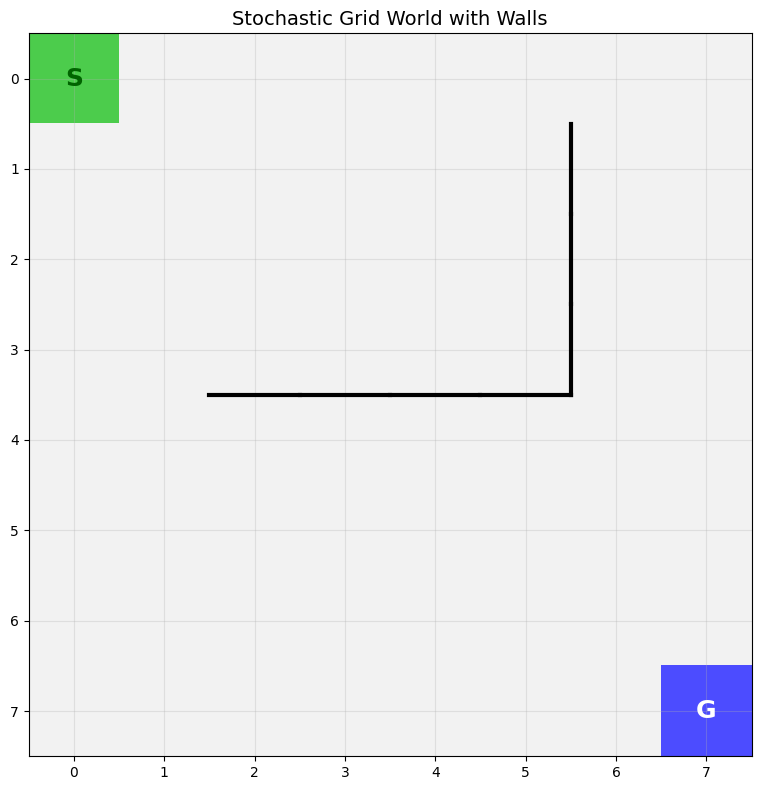

In [2]:
class StochasticGridWorld:
    """Grid world with stochastic transitions and internal walls."""

    def __init__(self):
        self.grid_h = GRID_H
        self.grid_w = GRID_W
        self.goal = GOAL
        self.slip_prob = 0.2  # Probability of slipping

        # Internal walls (blocked transitions)
        # Format: set of ((r1,c1), (r2,c2)) meaning movement between these cells is blocked
        self.walls = set()
        # Horizontal wall segment
        for c in range(2, 6):
            self.walls.add(((3, c), (4, c)))
            self.walls.add(((4, c), (3, c)))
        # Vertical wall segment
        for r in range(1, 4):
            self.walls.add(((r, 5), (r, 6)))
            self.walls.add(((r, 6), (r, 5)))

    def reset(self):
        self.state = START
        return self.state

    def _is_valid_move(self, from_pos, to_pos):
        """Check if movement is valid (within bounds and no wall)."""
        r, c = to_pos
        if r < 0 or r >= self.grid_h or c < 0 or c >= self.grid_w:
            return False
        if (from_pos, to_pos) in self.walls:
            return False
        return True

    def step(self, action):
        r, c = self.state

        # Stochastic transition
        if np.random.rand() < self.slip_prob:
            # Slip to a perpendicular direction
            if action in [0, 1]:  # up/down -> slip left/right
                action = np.random.choice([2, 3])
            else:  # left/right -> slip up/down
                action = np.random.choice([0, 1])

        dr, dc = MOVES[action]
        new_pos = (r + dr, c + dc)

        if self._is_valid_move(self.state, new_pos):
            self.state = new_pos

        reward = -0.1
        done = (self.state == self.goal)
        if done:
            reward = 10.0

        return self.state, reward, done

    def get_wall_segments(self):
        """Return wall segments for visualization."""
        segments = []
        processed = set()
        for (r1, c1), (r2, c2) in self.walls:
            key = (min(r1, r2), min(c1, c2), max(r1, r2), max(c1, c2))
            if key not in processed:
                processed.add(key)
                segments.append(((r1, c1), (r2, c2)))
        return segments


env = StochasticGridWorld()

# Visualize the environment
fig, ax = plt.subplots(figsize=(8, 8))
grid_display = np.ones((GRID_H, GRID_W, 3)) * 0.95

grid_display[START[0], START[1]] = [0.3, 0.8, 0.3]
grid_display[GOAL[0], GOAL[1]] = [0.3, 0.3, 1.0]

ax.imshow(grid_display, origin='upper')

# Draw walls
for (r1, c1), (r2, c2) in env.get_wall_segments():
    if r1 != r2:  # Horizontal wall between rows
        row = max(r1, r2)
        ax.plot([c1 - 0.5, c1 + 0.5], [row - 0.5, row - 0.5], 'k-', linewidth=3)
    else:  # Vertical wall between columns
        col = max(c1, c2)
        ax.plot([col - 0.5, col - 0.5], [r1 - 0.5, r1 + 0.5], 'k-', linewidth=3)

ax.text(START[1], START[0], 'S', ha='center', va='center', fontsize=18, fontweight='bold', color='darkgreen')
ax.text(GOAL[1], GOAL[0], 'G', ha='center', va='center', fontsize=18, fontweight='bold', color='white')

ax.set_title('Stochastic Grid World with Walls', fontsize=14)
ax.set_xticks(range(GRID_W))
ax.set_yticks(range(GRID_H))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Learned Dynamics Model

We learn a tabular model that stores observed transitions.
For each (state, action), the model remembers the resulting (next_state, reward).

In [3]:
class TabularDynamicsModel:
    """Tabular dynamics model that stores observed transitions."""

    def __init__(self):
        self.transitions = {}  # (state, action) -> list of (next_state, reward)
        self.visited_sa = []   # List of visited (state, action) pairs

    def update(self, state, action, next_state, reward):
        """Store an observed transition."""
        key = (state, action)
        if key not in self.transitions:
            self.transitions[key] = []
            self.visited_sa.append(key)
        self.transitions[key].append((next_state, reward))

    def predict(self, state, action):
        """Predict next state and reward by sampling from stored transitions."""
        key = (state, action)
        if key in self.transitions:
            idx = np.random.randint(len(self.transitions[key]))
            return self.transitions[key][idx]
        return None

    def sample_visited(self):
        """Sample a random previously visited (state, action) pair."""
        if len(self.visited_sa) == 0:
            return None
        idx = np.random.randint(len(self.visited_sa))
        return self.visited_sa[idx]

    def prediction_accuracy(self, test_transitions):
        """Compute prediction accuracy on a test set."""
        correct = 0
        total = 0
        for state, action, true_next, true_reward in test_transitions:
            pred = self.predict(state, action)
            if pred is not None:
                pred_next, pred_reward = pred
                if pred_next == true_next:
                    correct += 1
                total += 1
        return correct / max(total, 1)


print("Dynamics model class ready.")
print("The model stores observed (s, a) -> (s', r) transitions.")
print("For planning, it samples from stored transitions to simulate experience.")

Dynamics model class ready.
The model stores observed (s, a) -> (s', r) transitions.
For planning, it samples from stored transitions to simulate experience.


## 5. Dyna-Q Implementation

Dyna-Q combines direct RL, model learning, and planning in a single loop.

In [4]:
def run_dyna_q(env, num_episodes, planning_steps, alpha=ALPHA, gamma=GAMMA):
    """Run Dyna-Q with a given number of planning steps."""
    q_table = np.zeros((GRID_H, GRID_W, NUM_ACTIONS))
    model = TabularDynamicsModel()
    epsilon = EPSILON_START

    episode_rewards = []
    episode_steps = []
    model_accuracies = []
    test_buffer = []

    for ep in range(num_episodes):
        state = env.reset()
        ep_reward = 0.0
        step_count = 0

        for step in range(500):
            # Epsilon-greedy action selection
            if np.random.rand() < epsilon:
                action = np.random.randint(NUM_ACTIONS)
            else:
                action = np.argmax(q_table[state[0], state[1]])

            next_state, reward, done = env.step(action)

            # Direct RL update
            td_target = reward + (0 if done else gamma * np.max(q_table[next_state[0], next_state[1]]))
            q_table[state[0], state[1], action] += alpha * (td_target - q_table[state[0], state[1], action])

            # Model learning
            model.update(state, action, next_state, reward)

            # Store for accuracy testing
            if len(test_buffer) < 1000:
                test_buffer.append((state, action, next_state, reward))

            # Planning: use model for simulated updates
            for _ in range(planning_steps):
                sa = model.sample_visited()
                if sa is not None:
                    sim_state, sim_action = sa
                    result = model.predict(sim_state, sim_action)
                    if result is not None:
                        sim_next, sim_reward = result
                        sim_target = sim_reward + gamma * np.max(q_table[sim_next[0], sim_next[1]])
                        q_table[sim_state[0], sim_state[1], sim_action] += alpha * (
                            sim_target - q_table[sim_state[0], sim_state[1], sim_action])

            ep_reward += reward
            step_count += 1
            state = next_state

            if done:
                break

        episode_rewards.append(ep_reward)
        episode_steps.append(step_count)
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

        # Periodically check model accuracy
        if (ep + 1) % 10 == 0 and len(test_buffer) > 0:
            acc = model.prediction_accuracy(test_buffer[-100:])
            model_accuracies.append((ep, acc))

    return episode_rewards, episode_steps, model_accuracies, q_table, model


# Run experiments with different planning steps
results = {}
for k in PLANNING_STEPS:
    print(f"Running Dyna-Q with k={k} planning steps...")
    env_run = StochasticGridWorld()
    rewards, steps, acc, q, mdl = run_dyna_q(env_run, NUM_EPISODES, k)
    results[k] = {
        'rewards': rewards,
        'steps': steps,
        'accuracy': acc,
        'q_table': q,
        'model': mdl
    }
    print(f"  k={k}: Mean reward (last 50): {np.mean(rewards[-50:]):.3f}, "
          f"Mean steps (last 50): {np.mean(steps[-50:]):.1f}")

Running Dyna-Q with k=0 planning steps...


  k=0: Mean reward (last 50): 7.938, Mean steps (last 50): 21.6
Running Dyna-Q with k=5 planning steps...


  k=5: Mean reward (last 50): 7.780, Mean steps (last 50): 23.2
Running Dyna-Q with k=20 planning steps...


  k=20: Mean reward (last 50): 7.730, Mean steps (last 50): 23.7
Running Dyna-Q with k=50 planning steps...


  k=50: Mean reward (last 50): 7.614, Mean steps (last 50): 24.9


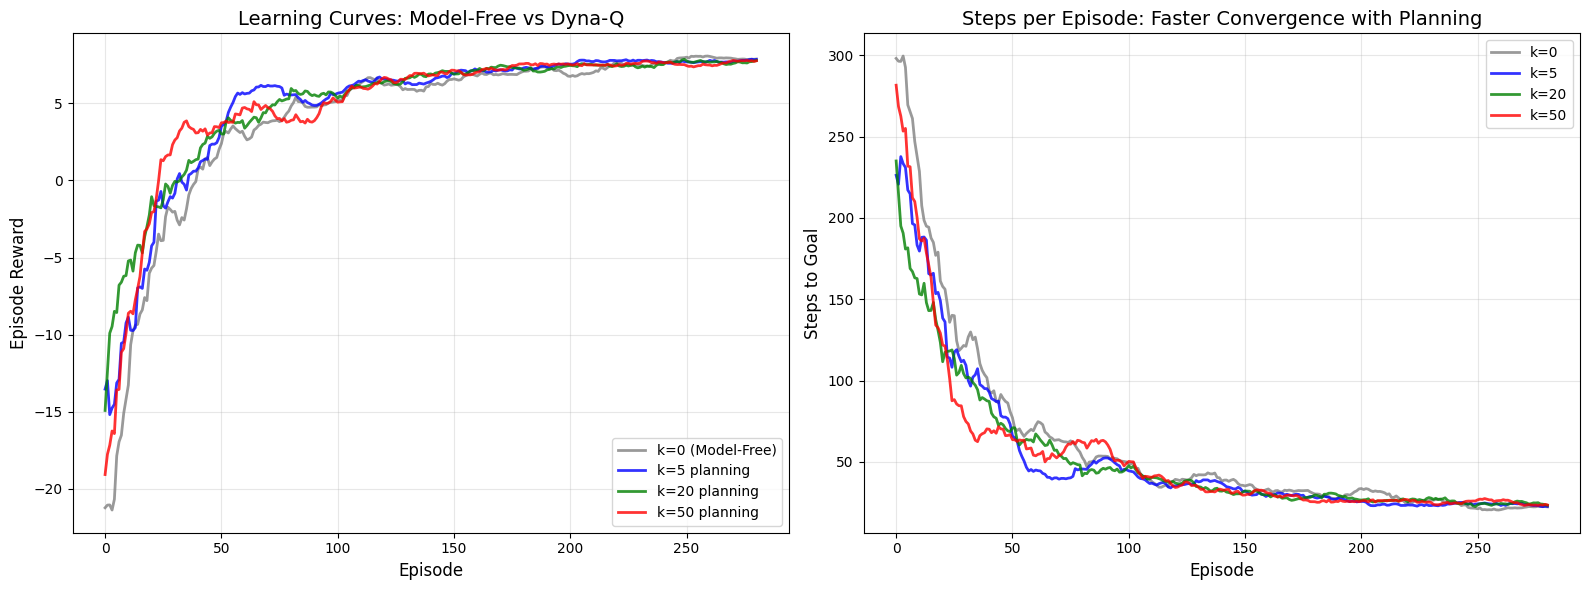

In [5]:
# Plot learning curves comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['gray', 'blue', 'green', 'red']
def smooth(data, w=20):
    if len(data) < w:
        return data
    return np.convolve(data, np.ones(w)/w, mode='valid')

for i, k in enumerate(PLANNING_STEPS):
    label = f'k={k} (Model-Free)' if k == 0 else f'k={k} planning'
    axes[0].plot(smooth(results[k]['rewards']), color=colors[i], linewidth=2, label=label, alpha=0.8)

axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Episode Reward', fontsize=12)
axes[0].set_title('Learning Curves: Model-Free vs Dyna-Q', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

for i, k in enumerate(PLANNING_STEPS):
    label = f'k={k}'
    axes[1].plot(smooth(results[k]['steps']), color=colors[i], linewidth=2, label=label, alpha=0.8)

axes[1].set_xlabel('Episode', fontsize=12)
axes[1].set_ylabel('Steps to Goal', fontsize=12)
axes[1].set_title('Steps per Episode: Faster Convergence with Planning', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Prediction Accuracy Over Training

The dynamics model improves as more transitions are observed.
Let us track how accurately the model predicts next states.

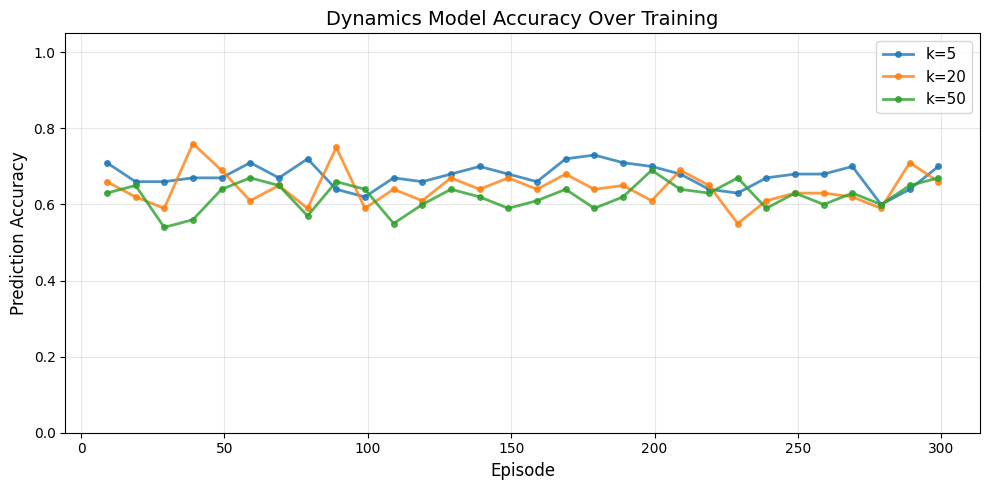

In [6]:
# Plot model accuracy for the k=20 case
fig, ax = plt.subplots(figsize=(10, 5))

for k in [5, 20, 50]:
    if len(results[k]['accuracy']) > 0:
        eps, accs = zip(*results[k]['accuracy'])
        ax.plot(eps, accs, 'o-', linewidth=2, markersize=4, label=f'k={k}', alpha=0.8)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Prediction Accuracy', fontsize=12)
ax.set_title('Dynamics Model Accuracy Over Training', fontsize=14)
ax.set_ylim([0, 1.05])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Learned Value Function and Policy Visualization

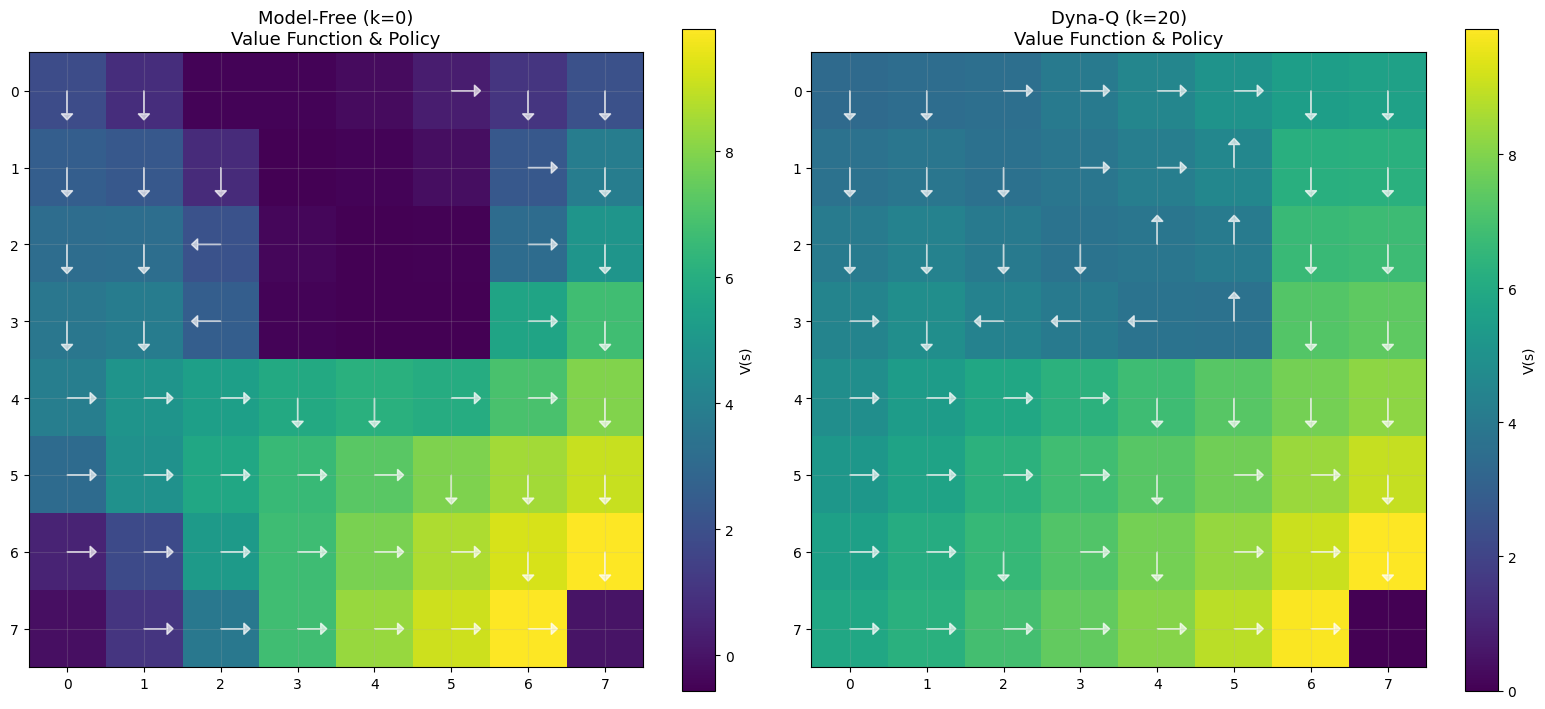

In [7]:
# Visualize value functions for model-free (k=0) and Dyna-Q (k=20)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, k, title in [(axes[0], 0, 'Model-Free (k=0)'), (axes[1], 20, 'Dyna-Q (k=20)')]:
    q = results[k]['q_table']
    v = np.max(q, axis=2)

    im = ax.imshow(v, origin='upper', cmap='viridis', aspect='equal')
    plt.colorbar(im, ax=ax, label='V(s)')

    # Draw policy arrows
    arrow_map = {0: (0, -0.3), 1: (0, 0.3), 2: (-0.3, 0), 3: (0.3, 0)}
    for r in range(GRID_H):
        for c in range(GRID_W):
            best_a = np.argmax(q[r, c])
            if np.max(q[r, c]) > 0.01:  # Only draw if meaningful
                dx, dy = arrow_map[best_a]
                ax.arrow(c, r, dx, dy, head_width=0.15, head_length=0.08,
                        fc='white', ec='white', alpha=0.7)

    ax.set_title(f'{title}\nValue Function & Policy', fontsize=13)
    ax.set_xticks(range(GRID_W))
    ax.set_yticks(range(GRID_H))
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 8. Sample Efficiency Analysis

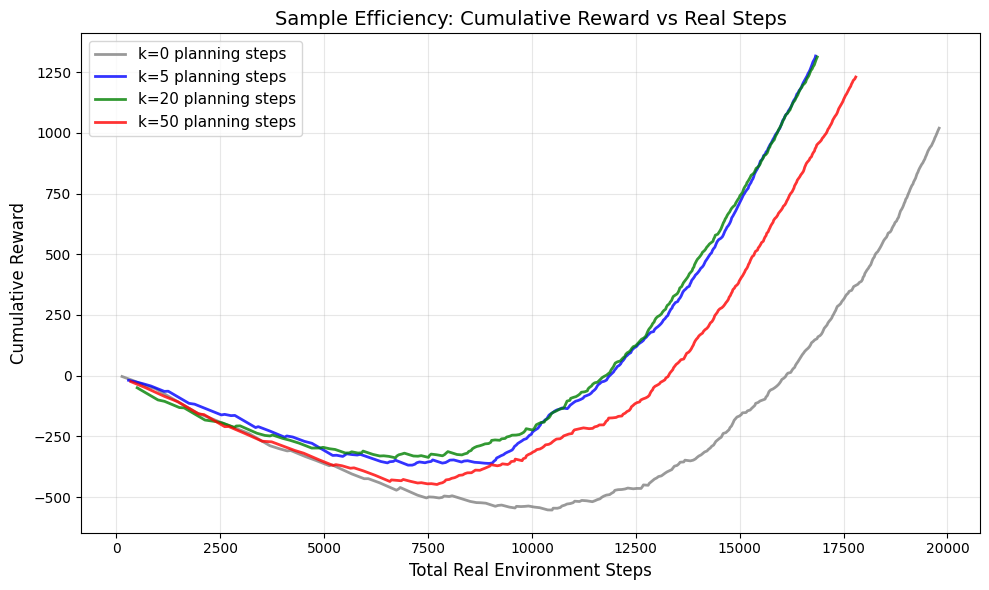

=== Sample Efficiency Summary ===
k= 0: Total real steps= 19800, Total reward=  1019.7, Final performance=7.938
k= 5: Total real steps= 16827, Total reward=  1317.0, Final performance=7.780
k=20: Total real steps= 16867, Total reward=  1313.0, Final performance=7.730
k=50: Total real steps= 17793, Total reward=  1230.5, Final performance=7.614


In [8]:
# Compute cumulative reward over real environment steps
fig, ax = plt.subplots(figsize=(10, 6))

for i, k in enumerate(PLANNING_STEPS):
    cumulative = np.cumsum(results[k]['rewards'])
    real_steps = np.cumsum(results[k]['steps'])
    ax.plot(real_steps, cumulative, color=colors[i], linewidth=2,
           label=f'k={k} planning steps', alpha=0.8)

ax.set_xlabel('Total Real Environment Steps', fontsize=12)
ax.set_ylabel('Cumulative Reward', fontsize=12)
ax.set_title('Sample Efficiency: Cumulative Reward vs Real Steps', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print("=== Sample Efficiency Summary ===")
for k in PLANNING_STEPS:
    total_steps = sum(results[k]['steps'])
    total_reward = sum(results[k]['rewards'])
    final_perf = np.mean(results[k]['rewards'][-50:])
    print(f"k={k:2d}: Total real steps={total_steps:6d}, "
          f"Total reward={total_reward:8.1f}, "
          f"Final performance={final_perf:.3f}")

## 9. Summary

This notebook demonstrated World Models and Model-Based RL:

1. **Stochastic Grid World:** Environment with probabilistic transitions and internal walls
2. **Dynamics Model:** Tabular model that stores and replays observed transitions
3. **Dyna-Q:** Combined real experience with model-based planning for faster learning
4. **Results:** More planning steps led to dramatically better sample efficiency

Key takeaways:
- Model-based RL learns much faster by reusing experience through planning
- The dynamics model accuracy improves as more transitions are observed
- There is a computation-vs-sample tradeoff: more planning = more compute per step but fewer steps needed
- In stochastic environments, the model naturally captures transition probabilities
- Dyna-Q is elegant: each real step generates k+1 learning updates instead of just 1